# 🧠 MiniLLM v2 — notebook unique (Kaggle · Colab · local)

Un seul notebook, dans l'ordre. **Chaque cellule d'entraînement reprend toute seule** si la session a été coupée : il suffit de la relancer.

| # | Étape | Durée indicative |
|---|-------|------------------|
| 0 | Configuration + installation + GPU | 2 min |
| 1 | *(recommandé la 1re fois)* test de bon fonctionnement | 2 min |
| 2 | Corpus propre + tokenizer 32k + tokenisation | 20–60 min |
| 3 | Pré-entraînement | plusieurs heures (voir les `k tok/s` dans le log) |
| 4 | Données SFT (avec **personnalité**) + fine-tuning (questions → réponses) | 20–60 min |
| 5 | Évaluation, démo, chat, export | 5 min |

💾 **Colab** : le code copie automatiquement les données sur le disque local avant l'entraînement (Drive est trop lent pour les lectures aléatoires) ; prévois environ 6 à 8 Go libres sur ton Drive (estimation).

⚠️ **Kaggle** : `/kaggle/working` ne survit pas à la session → à la fin, *Save Version* (ou ajoute la sortie précédente comme *Input*) et copie `BASE` si besoin. **Colab** : tout est stocké sur ton Google Drive.

## 0 · Configuration

In [5]:
import os, sys, subprocess, json, time

ON_COLAB  = "google.colab" in sys.modules
ON_KAGGLE = os.path.exists("/kaggle/working")

if ON_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE, CODE_DIR = "/content/drive/MyDrive/MiniLLM_v2", "/content/minillm_v2"
elif ON_KAGGLE:
    BASE, CODE_DIR = "/kaggle/working/MiniLLM_v2", "/kaggle/working/minillm_v2"
else:
    BASE, CODE_DIR = os.path.abspath("MiniLLM_v2_workdir"), os.path.abspath(".")
os.makedirs(BASE, exist_ok=True)

REPO_URL = "https://github.com/bono-p/minillm_v2.git"

# ── Paramètres (modifie ici) ─────────────────────────────────────────────
MODEL_SIZE  = "49M"      # 13M | 23M | 49M | 110M ...  (noms = VRAI nombre de paramètres, vocab 32k)
WIKI_DOCS   = 250_000    # articles Wikipédia FR (nettoyés)          — 0 pour désactiver
WEB_DOCS    = 300_000    # documents FineWeb-2 FR (web, plus naturel) — 0 pour désactiver
VOCAB_SIZE  = 32_000

PT_ITERS    = 10_000     # ~655 M tokens avec le batch ci-dessous (≈ 1 époque du corpus)
PT_LR       = 6e-4       # 1e-3 pour 13M/23M, 6e-4 pour 49M, 3e-4 au-dessus de 110M
PT_BATCH    = 16         # par GPU ; baisse à 8 si "CUDA out of memory"
PT_TOKENS_PER_STEP = 65_536   # batch effectif visé (réparti automatiquement sur les GPU)
MAX_MINUTES = 660 if ON_KAGGLE else 0   # arrêt propre avant la limite de session (Kaggle : 12 h)

SFT_EPOCHS  = 3
SFT_ALPACA, SFT_OASST, SFT_PIAF = 30_000, 3_000, 2_000
PERSONA_FILE, PERSONA_REPEAT = "personnalite.jsonl", 20   # ≤ 30 Q/R sur le modèle lui-même ; chaque Q/R est répétée 20x dans train

DATA   = f"{BASE}/data"
PT_OUT = f"{BASE}/checkpoints/pretrain"
SFT_OUT = f"{BASE}/checkpoints/sft"
print("BASE =", BASE)

import shutil
def local_copy(sub, refresh=False):
    """Colab : les données sont lues depuis le disque LOCAL (rapide) et non depuis Drive (lent en accès aléatoire).
    Les checkpoints, eux, restent sur Drive pour survivre aux coupures."""
    if not ON_COLAB:
        return f"{DATA}/{sub}"
    root, dst = "/content/minillm_local", f"/content/minillm_local/{sub}"
    os.makedirs(root, exist_ok=True)
    if refresh and os.path.exists(dst):
        shutil.rmtree(dst)
    if not os.path.exists(f"{dst}/meta.json"):
        print(f"Copie de {sub} sur le disque local…"); shutil.copytree(f"{DATA}/{sub}", dst)
    shutil.copy(f"{DATA}/tokenizer.json", f"{root}/tokenizer.json")
    return dst

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE = /content/drive/MyDrive/MiniLLM_v2


In [2]:
# Installation + récupération du code (si le dossier existe déjà : simple mise à jour)
!pip -q install tokenizers datasets
if not os.path.exists(os.path.join(CODE_DIR, "train.py")):
    !git clone {REPO_URL} {CODE_DIR}
elif os.path.exists(os.path.join(CODE_DIR, ".git")):
    !git -C {CODE_DIR} pull --ff-only
os.chdir(CODE_DIR); sys.path.insert(0, CODE_DIR)

import torch
N_GPU = torch.cuda.device_count()
print("GPU :", [torch.cuda.get_device_name(i) for i in range(N_GPU)] or "aucun (CPU : uniquement pour tester)")
if N_GPU:
    cap = torch.cuda.get_device_capability(0)
    print(f"Capacité de calcul {cap[0]}.{cap[1]} ->", "bf16 natif" if cap[0] >= 8 else "fp16 + GradScaler (T4/P100 : pas de bf16 natif ; le code choisit tout seul)")

PT_ACCUM = max(1, PT_TOKENS_PER_STEP // (PT_BATCH * 512 * max(1, N_GPU)))
print(f"Batch effectif : {PT_BATCH} x {PT_ACCUM} x {max(1, N_GPU)} GPU x 512 = {PT_BATCH * PT_ACCUM * max(1, N_GPU) * 512:,} tokens/pas")

Cloning into '/content/minillm_v2'...
remote: Enumerating objects: 270, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 270 (delta 58), reused 73 (delta 28), pack-reused 155 (from 1)
Receiving objects: 100% (270/270), 326.08 KiB | 3.84 MiB/s, done.
Resolving deltas: 100% (137/137), done.
GPU : aucun (CPU : uniquement pour tester)
Batch effectif : 16 x 8 x 1 GPU x 512 = 65,536 tokens/pas


## 1 · Test de bon fonctionnement (recommandé la 1re fois, sans internet ni GPU)
Teste tout le pipeline sur un mini modèle : corpus → tokenizer → pré-entraînement → **reprise** → SFT → génération.

In [ ]:
!python smoke_test.py 2>&1 | tail -15

it    210/254 | loss 4.1368 | lr 3.41e-05 | gnorm 4.73 | 11.3k tok/s | 0.1M tok | 0.1 min
it    220/254 | loss 4.3748 | lr 2.86e-05 | gnorm 5.70 | 19.6k tok/s | 0.1M tok | 0.1 min
  ┌ EVAL it    220 | val_loss 4.2222 (ppl 68.2) | 2,239 tokens évalués | best 4.2222 ★ nouveau best
it    230/254 | loss 4.2696 | lr 2.44e-05 | gnorm 5.88 | 14.4k tok/s | 0.1M tok | 0.1 min
it    240/254 | loss 4.1516 | lr 2.16e-05 | gnorm 12.61 | 19.6k tok/s | 0.1M tok | 0.1 min
  ┌ EVAL it    240 | val_loss 4.2000 (ppl 66.7) | 2,239 tokens évalués | best 4.2000 ★ nouveau best
it    250/254 | loss 4.3280 | lr 2.02e-05 | gnorm 1.96 | 9.0k tok/s | 0.1M tok | 0.1 min
it    254/254 | loss 4.2122 | lr 2.00e-05 | gnorm 2.75 | 11.9k tok/s | 0.1M tok | 0.1 min
  ┌ EVAL it    254 | val_loss 4.1887 (ppl 65.9) | 2,239 tokens évalués | best 4.1887 ★ nouveau best
✅ terminé à it=254 | meilleure val_loss=4.1887 -> /tmp/tmpman_9yvx/ckpt_sft/best.pt

▶ 6/6 génération (chat avec KV-cache)
Réponse (modèle minuscule non entraîn

## 2 · Corpus propre → tokenizer → binaires
* Wikipédia FR **nettoyé** (les phrases « trouées » du dump, du type *« né le  à Moulins »*, sont supprimées) + web FR optionnel.
* Split train/val **par document**, `<|endoftext|>` entre les documents.
* Tokenizer BPE 32k entraîné **sur ton corpus** (2–3× moins de paramètres d'embedding que cl100k).

In [ ]:
if os.path.exists(f"{DATA}/pretrain/meta.json"):
    print("✓ Données déjà prêtes :", json.load(open(f"{DATA}/pretrain/meta.json")))
else:
    !python prepare_data.py all --out {DATA} --wiki_docs {WIKI_DOCS} --web_docs {WEB_DOCS} --vocab_size {VOCAB_SIZE}

README.md: 100% 131k/131k [00:00<00:00, 131MB/s]
Resolving data files: 100% 17/17 [00:00<00:00, 15334.01it/s]
  … 20,000 documents (39 M caractères)
  … 40,000 documents (79 M caractères)
  … 60,000 documents (119 M caractères)
  … 80,000 documents (161 M caractères)
  … 100,000 documents (200 M caractères)
  … 120,000 documents (237 M caractères)
  … 140,000 documents (275 M caractères)
  … 160,000 documents (311 M caractères)
  … 180,000 documents (349 M caractères)
  … 200,000 documents (387 M caractères)
  … 220,000 documents (425 M caractères)
  … 240,000 documents (464 M caractères)
README.md: 100% 329k/329k [00:00<00:00, 163MB/s]
Resolving data files: 100% 135/135 [00:00<00:00, 21715.48it/s]
  … 260,000 documents (513 M caractères)
  … 280,000 documents (568 M caractères)
  … 300,000 documents (625 M caractères)
  … 320,000 documents (688 M caractères)
  … 340,000 documents (754 M caractères)
  … 360,000 documents (823 M caractères)
  … 380,000 documents (901 M caractères)
  … 4

## 3 · Pré-entraînement
* Relancer la cellule = **reprise exacte** (checkpoint complet toutes les 500 it, même ordre de données, même LR).
* `best.pt` = meilleure `val_loss` mesurée sur une **val fixe** → fiable. `final.pt` = dernière itération.
* 2 GPU (Kaggle T4×2) : lancé automatiquement avec `torchrun` (DDP).

In [ ]:
PT_DATA = local_copy("pretrain")     # Colab : copie unique sur le disque local
args = (f"--mode pretrain --data_dir {PT_DATA} --out_dir {PT_OUT} --model_size {MODEL_SIZE} "
        f"--seq_len 512 --batch_size {PT_BATCH} --grad_accum {PT_ACCUM} --lr {PT_LR} --min_lr {PT_LR/10} "
        f"--max_iters {PT_ITERS} --warmup_iters 300 --eval_every 500 --save_every 500 --eval_iters 50 "
        f"--max_minutes {MAX_MINUTES}")
if N_GPU > 1:
    !torchrun --standalone --nproc_per_node={N_GPU} train.py {args}
else:
    !python train.py {args}

Copie de pretrain sur le disque local…
════════════════════════════════════════════════════════════════════════
MiniLLM v2 — PRETRAIN | 49M (48.5M params, dont 32.1M hors embeddings)
device=cuda:0 dtype=torch.float16 GPU x1 compile=False | batch 16x8x1
Pré-entraînement : 65,536 tokens/it | 10000 it = 655 M tokens (1.95 époque sur 336 M tokens)
Reprise à it=4000 | best_val_loss=3.4700
════════════════════════════════════════════════════════════════════════
it   4025/10000 | loss 3.4877 | lr 4.26e-04 | gnorm 0.32 | 3813.9k tok/s | 263.8M tok | 1.2 min
it   4050/10000 | loss 3.5051 | lr 4.24e-04 | gnorm 0.35 | 21.6k tok/s | 265.4M tok | 2.4 min
it   4075/10000 | loss 3.4952 | lr 4.22e-04 | gnorm 0.33 | 21.8k tok/s | 267.1M tok | 3.7 min
it   4100/10000 | loss 3.4871 | lr 4.20e-04 | gnorm 0.33 | 21.8k tok/s | 268.7M tok | 4.9 min
it   4125/10000 | loss 3.4839 | lr 4.18e-04 | gnorm 0.32 | 21.7k tok/s | 270.3M tok | 6.2 min
it   4150/10000 | loss 3.4818 | lr 4.16e-04 | gnorm 0.32 | 21.8k tok

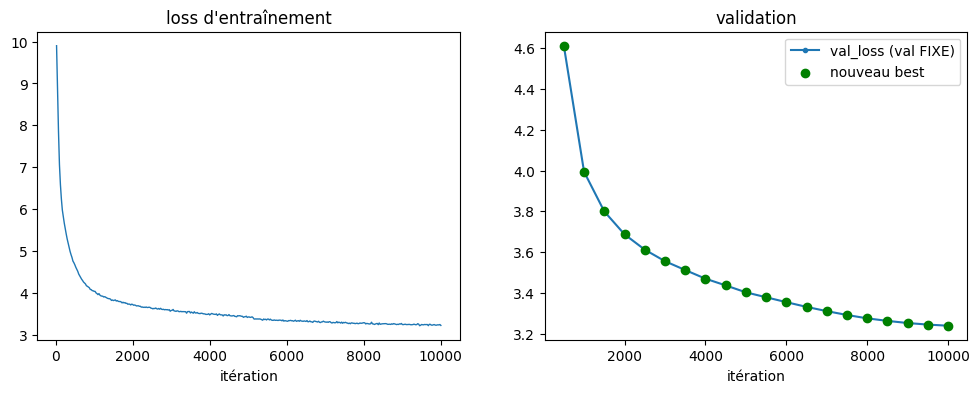

In [6]:
# Courbes (lues dans log.jsonl : rapide, pas besoin de recharger les checkpoints)
import matplotlib.pyplot as plt
def plot_log(path):
    rows = [json.loads(l) for l in open(path)]
    tr = [(r["it"], r["loss"]) for r in rows if r["type"] == "train"]
    ev = [(r["it"], r["val_loss"], r["improved"]) for r in rows if r["type"] == "eval"]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(*zip(*tr), lw=1); ax[0].set_title("loss d'entraînement"); ax[0].set_xlabel("itération")
    ax[1].plot([e[0] for e in ev], [e[1] for e in ev], "o-", ms=3, label="val_loss (val FIXE)")
    ax[1].scatter([e[0] for e in ev if e[2]], [e[1] for e in ev if e[2]], c="green", zorder=3, label="nouveau best")
    ax[1].set_title("validation"); ax[1].set_xlabel("itération"); ax[1].legend(); plt.show()
plot_log(f"{PT_OUT}/log.jsonl")

In [15]:
# Un texte de démonstration du modèle de base (il complète du texte, il ne répond pas aux questions : c'est normal)
!python generate.py --ckpt {PT_OUT}/best.pt --mode complete --prompt "Quelle est ton nom ?" --max_new 80

Modèle 49M | iter 10000 | val_loss 3.239384202957153 | device cpu
Quelle est ton nom ? Tu as déjà fait le tour du monde en 2016, et tu as aussi un peu de chance.

C’est quoi ton nom ?

Le nom de l’artiste est un nom de famille qui signifie littéralement « le nom de ta mère », ou « la fille de ton père ». C’est le surnom que l’on peut avoir dans la vie, à l’école ou 
[3.8s]


## 4 · Fine-tuning « questions → réponses »
Sources : Q/R synthétiques propres (hors-ligne) + French-Alpaca (réponses courtes) + OpenAssistant FR + PIAF (fenêtre centrée sur la réponse) + **`personnalite.jsonl`** (≤ 30 Q/R sur le modèle lui-même : son nom, son créateur, son caractère…).
La loss ne porte **que sur les réponses** ; exemples jamais tronqués ; early stopping ; `best.pt` choisi sur la loss des réponses.

In [16]:
# Si tu modifies personnalite.jsonl : supprime d'abord le dossier {DATA}/sft (ou change --out) pour reconstruire, puis ré-entraîne le SFT.
if os.path.exists(f"{DATA}/sft/meta.json"):
    print("✓ Données SFT déjà prêtes :", json.load(open(f"{DATA}/sft/meta.json"))["sources"])
else:
    !python sft_data.py --tokenizer {DATA}/tokenizer.json --out {DATA}/sft --alpaca {SFT_ALPACA} --oasst {SFT_OASST} --piaf {SFT_PIAF} --persona {PERSONA_FILE} --persona_repeat {PERSONA_REPEAT}

Sources :
  ✓ synthetic          4,190 exemples
README.md: 100% 253/253 [00:00<00:00, 702kB/s]

Acquiesce_data_110k_instructions.json: downloading bytes:  24% 12.4M/52.0M [00:03<00:08, 4.88MB/s,  992kB/s  ]
Acquiesce_data_110k_instructions.json: downloading bytes: 100% 13.2M/13.2M [00:04<00:00, 3.27MB/s, 1.08MB/s  ]
Acquiesce_data_110k_instructions.json: reconstructing file: 100% 52.0M/52.0M [00:04<00:00, 12.9MB/s, 4.71MB/s  ]
Generating train split: 100% 110368/110368 [00:02<00:00, 53460.82 examples/s]
  ✓ french_alpaca     30,000 exemples
README.md: 100% 10.2k/10.2k [00:00<00:00, 13.9MB/s]

data/train-00000-of-00001-b42a775f407cee(…): downloading bytes:   0% 0.00/39.5M [00:00<?, ?B/s]
data/train-00000-of-00001-b42a775f407cee(…): downloading bytes:  18% 7.26M/39.5M [00:00<00:03, 10.7MB/s,  481kB/s  ]
data/train-00000-of-00001-b42a775f407cee(…): downloading bytes:  95% 37.7M/39.5M [00:02<00:00, 12.3MB/s, 3.31MB/s  ]
data/train-00000-of-00001-b42a775f407cee(…): downloading bytes: 100% 3

In [ ]:
SFT_DATA = local_copy("sft", refresh=True)
!python train.py --mode sft --data_dir {SFT_DATA} --out_dir {SFT_OUT} --init_from {PT_OUT}/best.pt --epochs {SFT_EPOCHS}

Copie de sft sur le disque local…
════════════════════════════════════════════════════════════════════════
MiniLLM v2 — SFT | 49M (48.5M params, dont 32.1M hors embeddings)
device=cpu dtype=torch.float32 GPU x1 compile=False | batch 16x2x1
SFT : 36,457 exemples | 1139 it/époque | 3417 it (3 époques)
Nouveau run.
════════════════════════════════════════════════════════════════════════
  ┌ EVAL it      0 | val_loss 3.5587 (ppl 35.1) | 24,288 tokens évalués | best 3.5587 ★ nouveau best
it     10/3417 | loss 3.0894 | lr 4.00e-05 | gnorm 4.12 | 0.1k tok/s | 0.0M tok | 5.0 min
it     20/3417 | loss 2.6042 | lr 8.00e-05 | gnorm 3.28 | 0.2k tok/s | 0.0M tok | 7.5 min
it     30/3417 | loss 2.6164 | lr 1.20e-04 | gnorm 3.05 | 0.2k tok/s | 0.1M tok | 9.4 min
it     40/3417 | loss 2.4068 | lr 1.60e-04 | gnorm 2.49 | 0.1k tok/s | 0.1M tok | 11.7 min
it     50/3417 | loss 2.2899 | lr 2.00e-04 | gnorm 2.74 | 0.1k tok/s | 0.1M tok | 14.9 min
it     60/3417 | loss 2.3532 | lr 2.00e-04 | gnorm 2.22 | 0.

In [ ]:
plot_log(f"{SFT_OUT}/log.jsonl")

## 5 · Évaluation, démo, chat

In [ ]:
!python evaluate.py qa   --ckpt {SFT_OUT}/best.pt --sft_dir {DATA}/sft --n 300
!python evaluate.py demo --ckpt {SFT_OUT}/best.pt

In [12]:
# Chat dans le notebook (modifie la question et relance la cellule)
from generate import load_model, chat_reply
model, tok, _ = load_model(f"{SFT_OUT}/best.pt")
history = []
def ask(question, **kw):
    history.append({"role": "user", "content": question})
    answer = chat_reply(model, tok, history, max_new_tokens=100, temperature=0.6, top_k=40, top_p=0.9,
                        repetition_penalty=1.1, no_repeat_ngram=3, **kw)
    history.append({"role": "assistant", "content": answer})
    return answer
print(ask("Comment tu t'appelles ?"))      # personnalité (personnalite.jsonl)
print(ask("Qui t'a créé ?"))
print(ask("Quelle est la capitale du Cameroun ?"))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/MiniLLM_v2/checkpoints/sft/best.pt'

In [ ]:
# Export : modèle + tokenizer dans un zip à télécharger
import shutil
os.makedirs(f"{BASE}/export", exist_ok=True)
for f in ("best.pt", "tokenizer.json"):
    shutil.copy(f"{SFT_OUT}/{f}", f"{BASE}/export/{f}")
print(shutil.make_archive(f"{BASE}/minillm_export", "zip", f"{BASE}/export"))

## Dépannage rapide
* **CUDA out of memory** → `PT_BATCH = 8` (le batch effectif reste identique, l'accumulation s'ajuste toute seule).
* **Loss non finie** → baisse `PT_LR` de 30 %, relance (reprise automatique depuis le dernier checkpoint).
* **Session coupée** → relance simplement la même cellule : elle reprend à la dernière sauvegarde.
* **torchrun bloque sur Kaggle T4×2** → dans une cellule : `os.environ["NCCL_P2P_DISABLE"] = "1"` puis relance ; sinon `N_GPU = 1`.
* Le modèle répète en boucle → c'est le défaut n°1 des petits modèles : `no_repeat_ngram=3` et `repetition_penalty=1.1` sont déjà actifs ; baisse `temperature` (0.3–0.5).